In [21]:
folders = ["/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/aligned_output_type1", "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/aligned_output_type2", "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/aligned_output_type3"]
rmsd_matrices = {}
file_lists = {}

for folder in folders:
    files, rmsd_mat = rmsd_matrix(folder)
    rmsd_matrices[folder] = rmsd_mat
    file_lists[folder] = files

# Get top 10 closest neighbors per structure
top_neighbors = top_n_distances_unique(rmsd_matrices, file_lists, n=50)

# Example output for first structure in folder1
first_file = file_lists["/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/aligned_output_type1"][0]
print(f"Top 10 closest neighbors of {first_file}:")
for neighbor, dist in top_neighbors[first_file]:
    print(neighbor, dist)



Finding top distances: 100%|██████████| 840/840 [00:00<00:00, 9064.01it/s]

Top 10 closest neighbors of aligned_0038_4.xyz:
aligned_0038_4.xyz 0.0
aligned_0000_19.xyz 0.18647747301037013
aligned_0000_18.xyz 0.19334489585733403
aligned_0017_15.xyz 0.19650047568496282
aligned_0048_15.xyz 0.2106791247499777
aligned_0000_20.xyz 0.21135529736599137
aligned_0000_12.xyz 0.21477239225961206
aligned_0017_16.xyz 0.21505695353343804
aligned_0009_14.xyz 0.21518821183191394
aligned_0034_10.xyz 0.220536121463129
aligned_0017_17.xyz 0.22258558031968287
aligned_0000_11.xyz 0.22559607065394557
aligned_0000_13.xyz 0.22736752450639622
aligned_0009_15.xyz 0.2287650959135447
aligned_0039_13.xyz 0.2302178463969869
aligned_0034_15.xyz 0.23314261427414623
aligned_0014_5.xyz 0.23771717435326375
aligned_0035_8.xyz 0.238705724482922
aligned_0021_10.xyz 0.23974175865797073
aligned_0017_13.xyz 0.23990666983850195
aligned_0051_9.xyz 0.23994630689350757
aligned_0020_7.xyz 0.24093216819176166
aligned_0039_11.xyz 0.2428757033834385
aligned_0009_13.xyz 0.2440744567963159
aligned_0010_15.xyz 0.

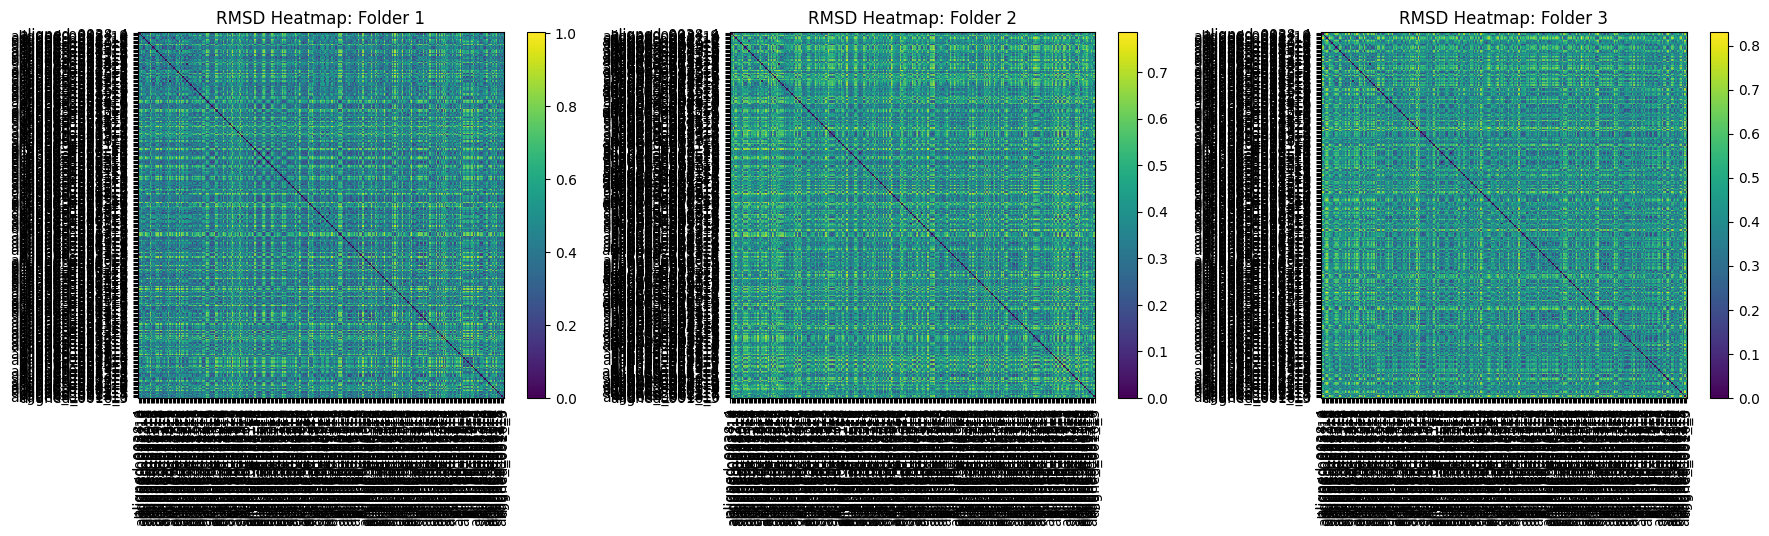

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Plot all 3 RMSD matrices as heatmaps
plt.figure(figsize=(18, 5))

for i, folder in enumerate(folders):
    rmsd_mat = rmsd_matrices[folder]
    files = file_lists[folder]

    plt.subplot(1, 3, i+1)
    im = plt.imshow(rmsd_mat, cmap='viridis', interpolation='nearest')
    plt.colorbar(im)
    plt.title(f"RMSD Heatmap: Folder {i+1}")
    plt.xticks(ticks=np.arange(len(files)), labels=[f.split('.')[0] for f in files], rotation=90)
    plt.yticks(ticks=np.arange(len(files)), labels=[f.split('.')[0] for f in files])

plt.tight_layout()
plt.show()


In [50]:
import numpy as np
import os
from itertools import permutations, product
from collections import defaultdict
from tqdm import tqdm

# -----------------------------
# Helper functions
# -----------------------------
def read_xyz(filename):
    atoms = []
    coords = []
    with open(filename) as f:
        lines = f.readlines()
        for line in lines[2:]:
            parts = line.split()
            if len(parts) < 4:
                continue
            atom, x, y, z = parts[0], float(parts[1]), float(parts[2]), float(parts[3])
            atoms.append(atom)
            coords.append([x, y, z])
    return np.array(atoms), np.array(coords)

def kabsch(P, Q):
    """Optimal rotation of P onto Q using Kabsch algorithm."""
    P_cent = P - P.mean(axis=0)
    Q_cent = Q - Q.mean(axis=0)
    C = np.dot(P_cent.T, Q_cent)
    V, S, Wt = np.linalg.svd(C)
    #if (np.linalg.det(V) * np.linalg.det(Wt)) < 0.0:
    #    V[:, -1] *= -1
    U = np.dot(V, Wt)
    P_rot = np.dot(P_cent, U)
    return P_rot + Q.mean(axis=0)

def rmsd(P, Q):
    diff = P - Q
    return np.sqrt((diff**2).sum() / len(P))

def atom_type_permutations(atoms):
    """Generate all atom-type-preserving permutations (brute-force)."""
    type_indices = defaultdict(list)
    for i, atom in enumerate(atoms):
        type_indices[atom].append(i)
    type_perms = {t: list(permutations(idxs)) for t, idxs in type_indices.items()}
    all_combos = product(*type_perms.values())
    perms_list = []
    for combo in all_combos:
        perm_indices = [0] * len(atoms)
        for indices, perm in zip(type_indices.values(), combo):
            for orig_idx, perm_idx in zip(indices, perm):
                perm_indices[orig_idx] = perm_idx
        perms_list.append(perm_indices)
    return perms_list

# -----------------------------
# Neighbor-aware alignment
# -----------------------------
def neighbor_aware_alignment_rmsd_matrix(reference_file,
                                         folder_path,
                                         rmsd_matrix_dict,
                                         file_lists_dict,
                                         subset_files=None,
                                         output_folder="aligned_output",
                                         neighbor_weight=1.0,
                                         epsilon=1e-6):

    import os
    from tqdm import tqdm

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Precompute filename → index maps for speed
    index_maps = {}
    for folder, files in file_lists_dict.items():
        index_maps[folder] = {
        f.replace("aligned_", ""): i
        for i, f in enumerate(files)
    }

    # Read reference
    ref_atoms, ref_coords = read_xyz(reference_file)

    # Load coords
    all_coords = {}
    for f in os.listdir(folder_path):
        if f.endswith(".xyz"):
            atoms, coords = read_xyz(os.path.join(folder_path, f))
            all_coords[f] = (atoms, coords)

    if subset_files is None:
        subset_files = list(all_coords.keys())

    aligned_coords_dict = {}
    aligned_files = []

    for filename in tqdm(subset_files, desc="Neighbor-aware alignment"):

        print("Aligned files so far:", aligned_files)
        print("Current file:", filename)


        mob_atoms, mob_coords = all_coords[filename]

        if list(mob_atoms) != list(ref_atoms):
            print(f"Skipping {filename}: atom types do not match reference.")
            continue

        perms = atom_type_permutations(mob_atoms)
        best_score = float('inf')
        best_coords = None

        for perm in perms:

            permuted_coords = mob_coords[perm]
            aligned_coords = kabsch(permuted_coords, ref_coords)

            # Base score: RMSD to reference
            base_score = rmsd(aligned_coords, ref_coords)

            neighbor_score = 0.0

            # Only consider already aligned files
            for aligned_file in aligned_files:

                min_rmsd = float('inf')

                # Search all RMSD matrices
                for folder, rmsd_mat in rmsd_matrix_dict.items():

                    #print("Checking folder:", folder)
                    #print("Filename present?", filename in index_maps[folder])
                    #print("Aligned present?", aligned_file in index_maps[folder])


                    if filename in index_maps[folder] and aligned_file in index_maps[folder]:

                        i = index_maps[folder][filename]
                        j = index_maps[folder][aligned_file]

                        min_rmsd = min(min_rmsd, rmsd_mat[i, j])

                if min_rmsd < float('inf'):
                    neighbor_score += 1.0 - np.log(min_rmsd + epsilon)

            # Final combined score
            total_score = base_score - neighbor_weight * neighbor_score

            if total_score < best_score:
                print(base_score, total_score)
                best_score = total_score
                best_coords = aligned_coords

        aligned_coords_dict[filename] = best_coords
        aligned_files.append(filename)

        # Save output
        output_file = os.path.join(output_folder, f"aligned_{filename}")
        with open(output_file, 'w') as f:
            f.write(f"{len(best_coords)}\n")
            f.write(f"Aligned to {reference_file}, score {best_score:.6f}\n")
            for atom, coord in zip(ref_atoms, best_coords):
                f.write(f"{atom} {coord[0]:.6f} {coord[1]:.6f} {coord[2]:.6f}\n")

    return aligned_coords_dict



In [52]:
folder_to_align = "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/unaligned"
k = 50  # number of structures to align

# Automatically select first k XYZ files from the folder
all_files_in_folder = [f for f in os.listdir(folder_to_align) if f.endswith(".xyz")]
subset_files = all_files_in_folder[:k]

print(f"Aligning {len(subset_files)} structures from {folder_to_align}:")
print(subset_files)

aligned_dict = neighbor_aware_alignment_rmsd_matrix(
    reference_file="/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/references/Type_2.xyz",
    folder_path=folder_to_align,
    rmsd_matrix_dict=rmsd_matrices,
    file_lists_dict=file_lists,
    subset_files=subset_files,
    neighbor_weight=0.1
)


Aligning 50 structures from /Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/polyalign/unaligned:
['0041_6.xyz', '0013_13.xyz', '0020_7.xyz', '0011_16.xyz', '0013_8.xyz', '0044_17.xyz', '0037_9.xyz', '0029_12.xyz', '0039_6.xyz', '0039_7.xyz', '0037_8.xyz', '0013_9.xyz', '0044_16.xyz', '0043_5.xyz', '0020_6.xyz', '0013_12.xyz', '0041_7.xyz', '0041_5.xyz', '0048_14.xyz', '0013_10.xyz', '0043_7.xyz', '0020_4.xyz', '0011_15.xyz', '0044_14.xyz', '0035_8.xyz', '0039_5.xyz', '0029_11.xyz', '0029_10.xyz', '0037_10.xyz', '0035_9.xyz', '0044_15.xyz', '0011_14.xyz', '0048_15.xyz', '0013_11.xyz', '0003_10.xyz', '0019_5.xyz', '0015_8.xyz', '0026_7.xyz', '0044_11.xyz', '0000_4.xyz', '0011_10.xyz', '0039_11.xyz', '0047_6.xyz', '0049_9.xyz', '0049_8.xyz', '0047_7.xyz', '0039_10.xyz', '0011_11.xyz', '0026_6.xyz', '0044_10.xyz']


Neighbor-aware alignment:   0%|          | 0/50 [00:00<?, ?it/s]

Aligned files so far: []
Current file: 0041_6.xyz
0.49312197567990174 0.49312197567990174
0.4261626579604961 0.4261626579604961
0.39120753767546307 0.39120753767546307
0.3831648674127216 0.3831648674127216


Neighbor-aware alignment:   2%|▏         | 1/50 [00:08<07:14,  8.86s/it]

Aligned files so far: ['0041_6.xyz']
Current file: 0013_13.xyz
0.8903189502637704 0.6717426438216597
0.8049245524108228 0.5863482459687122
0.7777671204620793 0.5591908140199686
0.7674733041109219 0.5488969976688112
0.7029580898601564 0.4843817834180457
0.4163101241204707 0.19773381767836004
0.28568464453417797 0.06710833809206732


...

Aligned files so far: ['0041_6.xyz', '0013_13.xyz', '0020_7.xyz', '0011_16.xyz', '0013_8.xyz', '0044_17.xyz', '0037_9.xyz', '0029_12.xyz', '0039_6.xyz', '0039_7.xyz', '0037_8.xyz', '0013_9.xyz', '0044_16.xyz', '0043_5.xyz', '0020_6.xyz', '0013_12.xyz', '0041_7.xyz', '0041_5.xyz', '0048_14.xyz', '0013_10.xyz', '0043_7.xyz', '0020_4.xyz', '0011_15.xyz', '0044_14.xyz', '0035_8.xyz', '0039_5.xyz', '0029_11.xyz', '0029_10.xyz', '0037_10.xyz', '0035_9.xyz', '0044_15.xyz', '0011_14.xyz', '0048_15.xyz', '0013_11.xyz', '0003_10.xyz', '0019_5.xyz', '0015_8.xyz', '0026_7.xyz', '0044_11.xyz', '0000_4.xyz', '0011_10.xyz']
Current file: 0039_11.xyz
0.8497946768825613 -7.5609812109426535
0.7979514566880356 -7.61282443113718
0.561608900814893 -7.849166987010323
0.3815199248715762 -8.02925596295364
0.1861201333547445 -8.22465575447047


Neighbor-aware alignment:  84%|████████▍ | 42/50 [13:39<03:48, 28.62s/it]

Aligned files so far: ['0041_6.xyz', '0013_13.xyz', '0020_7.xyz', '0011_16.xyz', '0013_8.xyz', '0044_17.xyz', '0037_9.xyz', '0029_12.xyz', '0039_6.xyz', '0039_7.xyz', '0037_8.xyz', '0013_9.xyz', '0044_16.xyz', '0043_5.xyz', '0020_6.xyz', '0013_12.xyz', '0041_7.xyz', '0041_5.xyz', '0048_14.xyz', '0013_10.xyz', '0043_7.xyz', '0020_4.xyz', '0011_15.xyz', '0044_14.xyz', '0035_8.xyz', '0039_5.xyz', '0029_11.xyz', '0029_10.xyz', '0037_10.xyz', '0035_9.xyz', '0044_15.xyz', '0011_14.xyz', '0048_15.xyz', '0013_11.xyz', '0003_10.xyz', '0019_5.xyz', '0015_8.xyz', '0026_7.xyz', '0044_11.xyz', '0000_4.xyz', '0011_10.xyz', '0039_11.xyz']
Current file: 0047_6.xyz
0.845599684047592 -6.910361747468226


Neighbor-aware alignment:  84%|████████▍ | 42/50 [13:41<02:36, 19.56s/it]


KeyboardInterrupt: 